In [1]:
import os
repo = 'boston-marathons'
counter = 0
max_depth = 50
current = os.getcwd()
while True:
    current_tmp = os.path.basename(os.getcwd())
    if current_tmp == repo:
        print(f"Main dir found: {os.getcwd()}")
        break
    else:
        os.chdir("..")
        counter += 1
        if counter >= max_depth:
            print(f"Reached {max_depth} levels up — '{repo}' not found.")
            os.chdir(current)
            print(f"Current path: {current}")
            break

Main dir found: D:\Scripts\Data Science\projekty\repo\boston-marathons


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as math

In [3]:
df = pd.read_csv('./data/clean/boston_features.csv')
df15 = df[df['Year'] == 2015]
df16 = df[df['Year'] == 2016]
df17 = df[df['Year'] == 2017]

In [4]:
df.head()

,Name,M/F,Age,Age Group,Country,Continent,City,Pace,5K,10K,15K,20K,25K,30K,35K,40K,Official Time,Year,Place_Year,Place_Global
0,"Desisa, Lelisa",M,25,22–25,ETH,Africa,Ambo,3.065431,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.044167,2.154722,2015,1,1
1,"Kirui, Geoffrey",M,24,22–25,KEN,Africa,Keringet,3.075787,0.256944,0.507778,0.762222,1.020833,1.283056,1.550278,1.805278,2.048056,2.160278,2017,1,2
2,"Tsegay, Yemane Adhane",M,30,30–33,ETH,Africa,Addis Ababa,3.086144,0.245278,0.495278,0.749444,1.007778,1.268611,1.533056,1.799722,2.045000,2.163333,2015,2,3
3,"Rupp, Galen",M,30,30–33,USA,North America,Portland,3.086144,0.256667,0.507500,0.762222,1.020833,1.283056,1.550278,1.805278,2.053889,2.166111,2017,2,4
4,"Chebet, Wilson",M,29,26–29,KEN,Africa,Marakwet,3.096500,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.050278,2.172778,2015,3,5


In [5]:
plt.style.use('seaborn-v0_8-whitegrid')

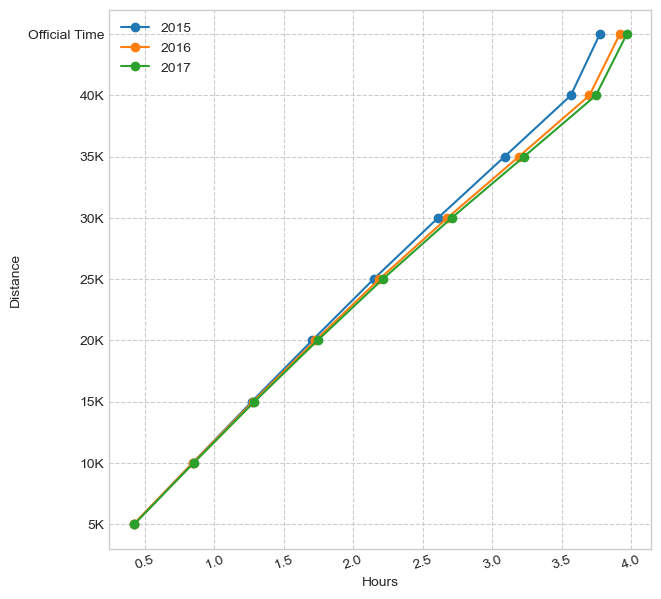

In [6]:
fig, ax = plt.subplots(figsize=(7,7))

def plot_avg_splits_by_year(ax):
    
    y = df.columns[8:17]
    dfs = [df15, df16, df17]
    
    for dfxx in dfs:
        
        x = [
            dfxx['5K'].mean(),
            dfxx['10K'].mean(),
            dfxx['15K'].mean(),
            dfxx['20K'].mean(),
            dfxx['25K'].mean(),
            dfxx['30K'].mean(), 
            dfxx['35K'].mean(),
            dfxx['40K'].mean(),
            dfxx['Official Time'].mean()
        ]
        ax.plot(x, y, marker='o', label=int(dfxx['Year'].mean()))
    
        
    
    ax.grid(linestyle='--')
    ax.legend()
    
    ax.set(
        title="",
        xlabel="Hours",
        ylabel="Distance",
    )
    ax.tick_params(axis='x', rotation=20)
    
plot_avg_splits_by_year(ax)
plt.show()

In [7]:
continent_colors = {
    'Africa': 'brown',
    'Europe': 'blue',
    'Asia': 'pink',
    'North America': 'orange',
    'South America': 'green',
    'Oceania': 'cyan'
}

def df_by_continent(df, continent):
    df_filtered = df[df['Continent'] == continent]
    color = continent_colors.get(continent, 'gray')
    return df_filtered, color

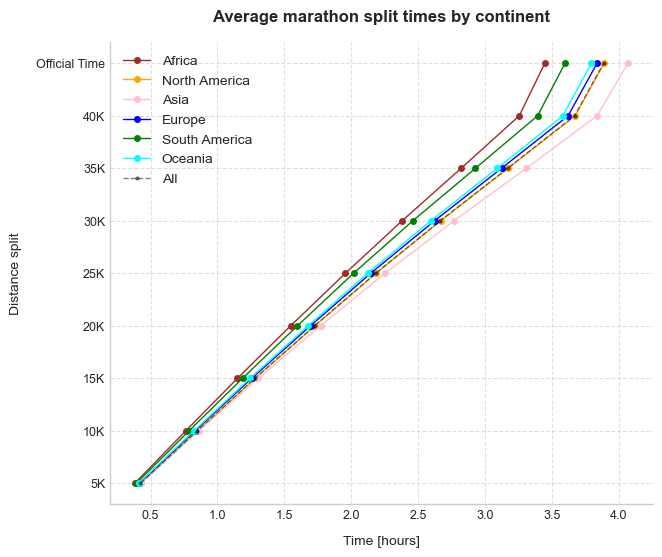

In [8]:
splits = ['5K', '10K', '15K', '20K', '25K', '30K', '35K', '40K', 'Official Time']

fig, ax = plt.subplots(figsize=(7,6))

for continent in df['Continent'].unique():
    df_filtered, color = df_by_continent(df, continent)

    y = splits
    x = [df_filtered[split].mean() for split in splits]
    ax.plot(x, y, color=color, marker='o', label=continent, linewidth=1, markersize=4, linestyle='-')
    
ax.plot([df[split].mean() for split in splits], y, marker='o', label='All', color='black', linewidth=1, markersize=2, alpha=0.5, linestyle='--')

ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_title("Average marathon split times by continent", pad=15, fontsize=12, weight='bold')
ax.set_xlabel("Time [hours]", labelpad=10)
ax.set_ylabel("Distance split", labelpad=10)
ax.tick_params(axis='both', labelsize=9)

plt.show()

In [9]:
df.head()

,Name,M/F,Age,Age Group,Country,Continent,City,Pace,5K,10K,15K,20K,25K,30K,35K,40K,Official Time,Year,Place_Year,Place_Global
0,"Desisa, Lelisa",M,25,22–25,ETH,Africa,Ambo,3.065431,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.044167,2.154722,2015,1,1
1,"Kirui, Geoffrey",M,24,22–25,KEN,Africa,Keringet,3.075787,0.256944,0.507778,0.762222,1.020833,1.283056,1.550278,1.805278,2.048056,2.160278,2017,1,2
2,"Tsegay, Yemane Adhane",M,30,30–33,ETH,Africa,Addis Ababa,3.086144,0.245278,0.495278,0.749444,1.007778,1.268611,1.533056,1.799722,2.045000,2.163333,2015,2,3
3,"Rupp, Galen",M,30,30–33,USA,North America,Portland,3.086144,0.256667,0.507500,0.762222,1.020833,1.283056,1.550278,1.805278,2.053889,2.166111,2017,2,4
4,"Chebet, Wilson",M,29,26–29,KEN,Africa,Marakwet,3.096500,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.050278,2.172778,2015,3,5


In [10]:
df.columns

Index(['Name', 'M/F', 'Age', 'Age Group', 'Country', 'Continent', 'City',
       'Pace', '5K', '10K', '15K', '20K', '25K', '30K', '35K', '40K',
       'Official Time', 'Year', 'Place_Year', 'Place_Global'],
      dtype='object')

Axes(0.125,0.11;0.775x0.77)


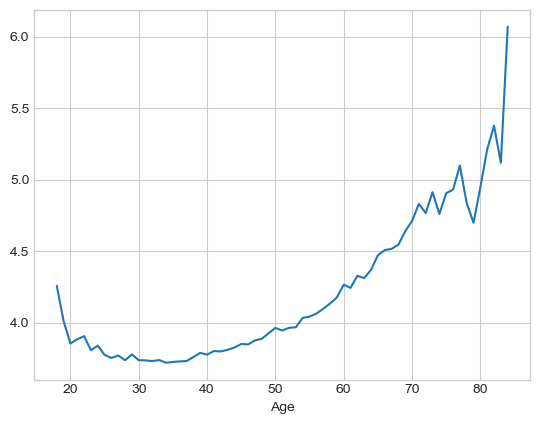

In [11]:
print(df.groupby("Age")["Official Time"].mean().plot())

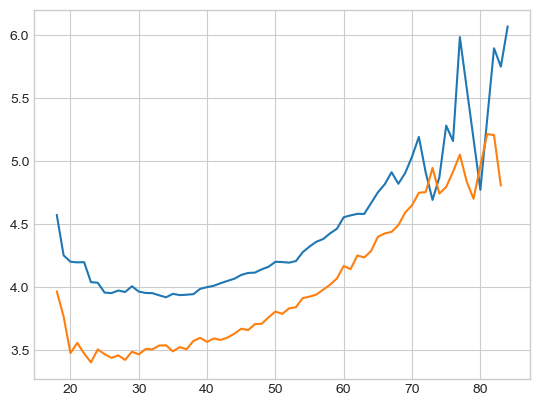

In [12]:
fig, ax = plt.subplots()

data = df.groupby(["Age", "M/F"])["Official Time"].mean().reset_index()

for MF in data["M/F"].unique():
    subset = data[data["M/F"] == MF]
    ax.plot(subset['Age'], subset["Official Time"])

plt.show()

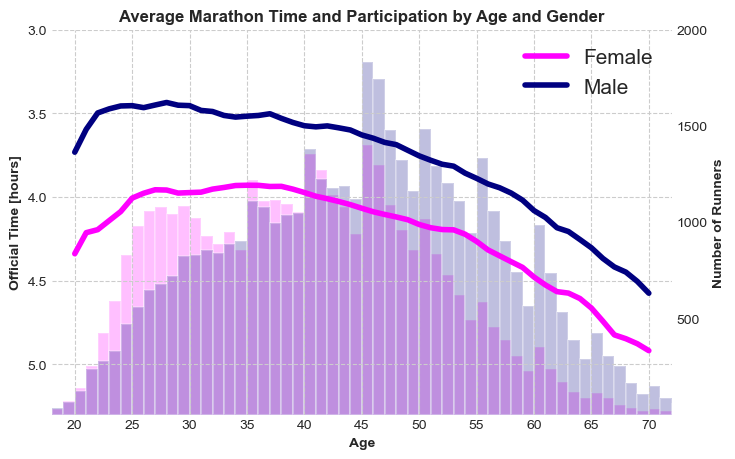

In [64]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()

data = df.groupby(["Age", "M/F"])["Official Time"].mean().reset_index()
data = data[data['Age'] < 71]

for MF in data["M/F"].unique():
    subset = data[data["M/F"] == MF].sort_values(by="Age")
    subset["Smooth"] = subset["Official Time"].rolling(3).mean()
    if MF == "M":
        c='navy'
        l='Male'
        a=0.25
    else: 
        c='magenta'
        l='Female'
        a=0.25
    ax2.hist(df["Age"][df["M/F"] == MF], bins=range(18,84,1), color=c, alpha=a, edgecolor='white', linewidth=1.5)
    ax1.plot(subset["Age"], subset["Smooth"], label=l, linewidth=4, color=c)
    
    
# descriptions

# ax
ax1.set_title("Average Marathon Time and Participation by Age and Gender", weight='bold')
ax1.set_xlabel("Age", weight='bold')
ax1.set_ylabel("Official Time [hours]", weight='bold')

ax1.set_xlim(18,72)
ax1.set_xticks(range(20,71,5))

ax1.set_ylim(3,5.3)


ax1.grid(True, linestyle='--', alpha=1)
ax1.invert_yaxis()
ax1.set_zorder(3)
ax1.patch.set_visible(False)
ax2.set_zorder(2)
ax2.patch.set_visible(True)

# ax2
ax2.set_ylabel("Number of Runners", weight='bold')

# ax2.set_ylim(0, 2000)
ax2.set_ylim(0, ax2.get_ylim()[1] * 0.8)
ax2.set_yticks(range(500,2001,500))

ax2.grid(False)

spines = ["top", "bottom", "left", "right"]
for spine in spines:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

ax1.legend(fontsize=15)

# plt.savefig("test/chart_1.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
data

,Age,M/F,Official Time
0,18,F,4.570435
1,18,M,3.963255
2,19,F,4.248690
3,19,M,3.762090
4,20,F,4.198024
...,...,...,...
125,82,F,5.894444
126,82,M,5.204537
127,83,F,5.748056
128,83,M,4.802778


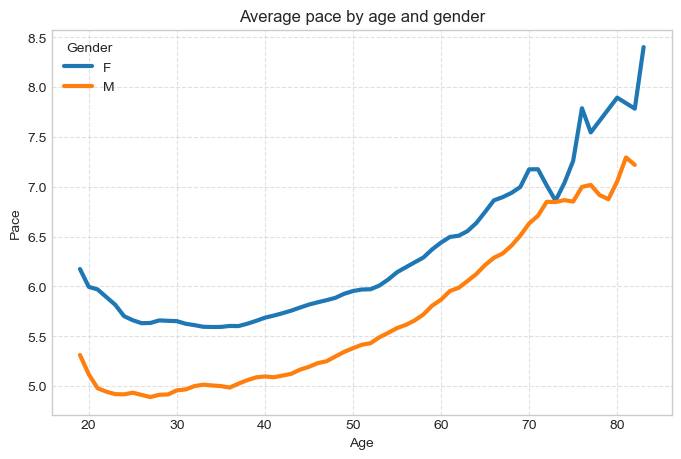

In [15]:
fig, ax = plt.subplots(figsize=(8,5))

data = df.groupby(["Age", "M/F"])["Pace"].mean().reset_index()


for MF in data["M/F"].unique():
    subset = data[data["M/F"] == MF].sort_values("Age")
    subset["Smooth"] = subset["Pace"].rolling(window=3, center=True).mean()
    ax.plot(subset["Age"], subset["Smooth"], label=MF, linewidth=3)


ax.set(
    title="Average pace by age and gender",
    xlabel="Age",
    ylabel="Pace"
)
ax.legend(title="Gender")
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [16]:
subset

,Age,M/F,Pace,Smooth
1,18,M,5.641209,NaN
3,19,M,5.355076,5.312808
5,20,M,4.942138,5.118254
7,21,M,5.057549,4.979083
9,22,M,4.937562,4.944382
...,...,...,...,...
121,79,M,6.685658,6.875698
123,80,M,7.060095,7.054285
124,81,M,7.417101,7.295107
126,82,M,7.408125,7.220103
